In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from sentence_transformers import SentenceTransformer, util
import urllib
import distance

import pyodbc
from tabulate import tabulate
import html
from sqlalchemy import create_engine 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Deekshitha.m\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Deekshitha.m\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


<h2>Connecting to DB & cleaning the dataset</h2>


In [2]:
server = '172.16.16.160'
database = 'IDR_RAS_DEV'
username = 'Test'

password = 'Test@1234'

conn_str = (
           f"UID={username};"
           f"PWD={{{password}}};"
           f"DRIVER={{ODBC Driver 17 for SQL Server}};"
           f"SERVER={server};"
           f"DATABASE={database};"
)

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

query = "SELECT QuestionNo,Question FROM sentences_Full"

df = pd.read_sql(query, engine)

#Cleaning the html content
from bs4 import BeautifulSoup

def strip_tags(html_content):
    if not html_content or pd.isna(html_content):
         return ""
    
    html_content = html.unescape(html_content)
    soup = BeautifulSoup(html_content, "html.parser")
    clean_text = soup.get_text(separator=" ")
    clean_text = re.sub(r'<[^>]*>', ' ', clean_text)
    clean_text = re.sub(r'\s+', ' ', clean_text)
    # Remove non-printable characters and collapse extra spaces
    printable_text = "".join(c for c in clean_text if c.isprintable())
    return " ".join(printable_text.split()).strip()

df['Question_clean'] = df['Question'].apply(strip_tags)


print("Data successfully extracted from SSMS!")
print(df[['Question_clean']].head(10))

Data successfully extracted from SSMS!
                                      Question_clean
0  Read the passage given below and answer the qu...
1  Which one of the following will cause harm to ...
2  Which one of the following is a hypoglycemic a...
3  All are the causes of environmental pollution,...
4  All of the following practices must be followe...
5  Which of the following is not an appropriate m...
6  Which of the following statements is NOT true ...
7  The founder of the Rational Behavior Emotive T...
8  The nurse provides a safe environment for a pa...
9  Read the passage given below and answer the qu...


In [3]:
df.shape

(55181, 3)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55181 entries, 0 to 55180
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   QuestionNo      55181 non-null  int64
 1   Question        55181 non-null  str  
 2   Question_clean  55181 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.3 MB


In [5]:
df.describe()

,QuestionNo
count,55181.000000
mean,54867.198909
std,37590.921134
min,104.000000
25%,20621.000000
50%,50223.000000
75%,90858.000000
max,126744.000000


<h3>Dropping the empty strings</h3>

In [6]:
# Force the column to be a string and remove ALL invisible padding/whitespace
df['Question_clean'] = df['Question_clean'].astype(str).str.strip()

# Replace the blank space with null 
import numpy as np
df['Question_clean'] = df['Question_clean'].replace('', np.nan)


print(f"Nulls found: {df['Question_clean'].isna().sum()}")

# Drop the null values
df.dropna(subset=['Question_clean'], inplace=True)

print(f"Final row count: {len(df)}")


Nulls found: 326
Final row count: 54855


In [7]:
print(df['Question_clean'].isna().sum())

0


<h3>Finding the duplicates</h3>

In [8]:
import faiss

# 1. Load the model
model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')  #switch to gpu
embeddings = model.encode(df['Question_clean'].tolist(), convert_to_numpy=True, show_progress_bar=True)

# 2. Normalize and build FAISS Similarity Index
faiss.normalize_L2(embeddings)
d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)    #Switch to IndexIVFFlat or HNSW for millions of rows
index.add(embeddings)

# 3. Goes through all the questions
D, I = index.search(embeddings, k=2)

# 4. Flag duplicates based on threshold
threshold = 0.90
is_duplicate = []
for i in range(len(embeddings)):
    if D[i][1] > threshold:
        is_duplicate.append(1)
    else:
        is_duplicate.append(0)

df['is_duplicate'] = is_duplicate


Loading weights: 100%|██████████| 103/103 [00:01<00:00, 86.61it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1715/1715 [36:19<00:00,  1.27s/it]


<h4> Distribution of Questions </h4>

--- Data Check ---
status
Non-Duplicate    33578
Duplicate        21277
Name: count, dtype: int64


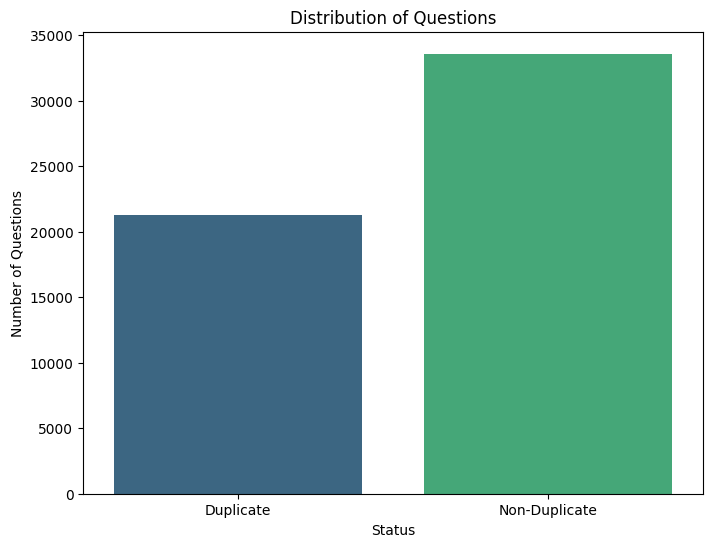

In [9]:
import faiss

# 1. RE-FLAG (Restores the 0s and 1s without re-encoding)
threshold = 0.85
df['is_duplicate'] = (D[:, 1] > threshold).astype(int)

# 2. Mapping Duplicate and Non-Duplicate
label_map = {0: 'Non-Duplicate', 1: 'Duplicate'}
df['status'] = df['is_duplicate'].map(label_map)

# 3. VERIFY DATA
print("--- Data Check ---")
print(df['status'].value_counts())

# 4. Plotting
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='status', palette='viridis')
plt.title("Distribution of Questions")
plt.xlabel("Status")
plt.ylabel("Number of Questions")
plt.show()


<h4>Frequency of Top 10 Duplicate Questions</h4>

Total Unique Questions: 51822
Questions appearing more than once: 2035
The most repeated question appears 117 times.


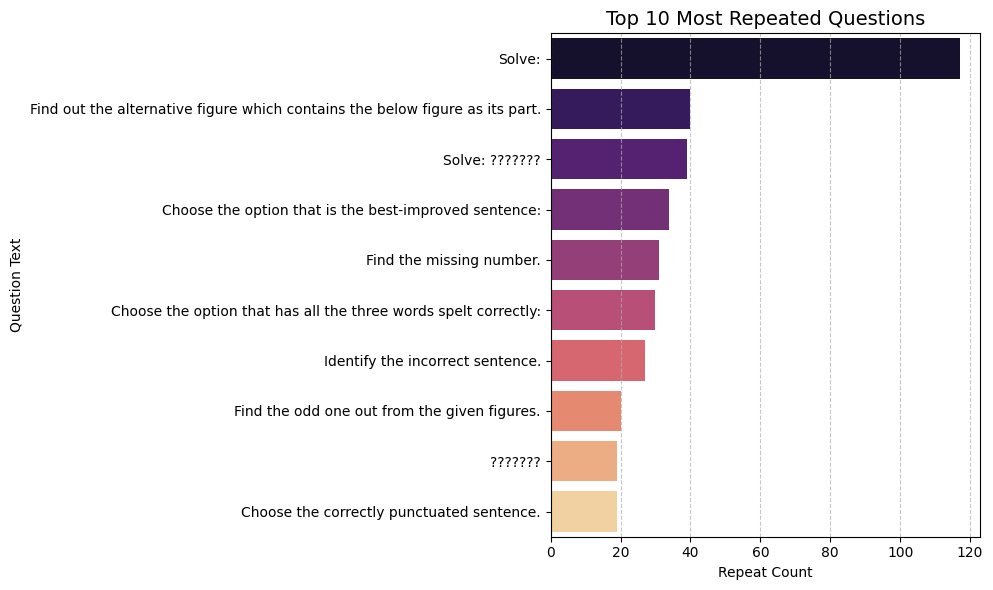

In [10]:
counts = df['Question_clean'].value_counts()

# 1. Extract stats directly from the Series
total_unique = len(counts)
repeated_questions = counts[counts > 1]
repeated_count = len(repeated_questions)
max_repeats = counts.max()

print(f"Total Unique Questions: {total_unique}")
print(f"Questions appearing more than once: {repeated_count}")
print(f"The most repeated question appears {max_repeats} times.")

# 2. Create Summary Table for Top 10 
top_10 = repeated_questions.head(10).reset_index()
top_10.columns = ['Question Text', 'Repeat Count']

plt.figure(figsize=(10, 6))

sns.barplot(data=top_10, x='Repeat Count', y='Question Text', palette='magma')

if max_repeats < 20:
    plt.xticks(range(1, int(max_repeats) + 1))

plt.title("Top 10 Most Repeated Questions", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<h4>Frequency of all Duplicate Questions</h4>

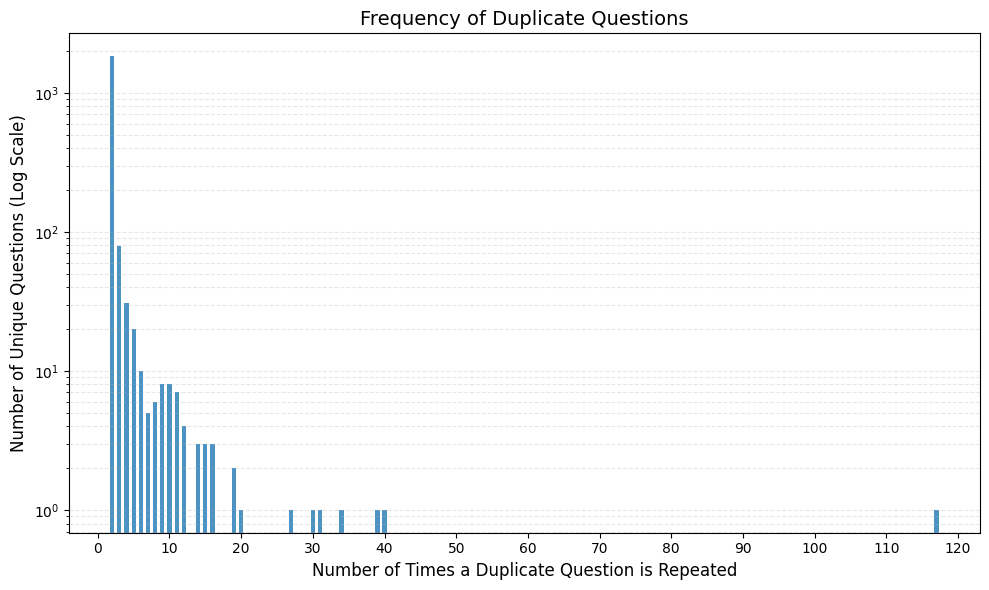

Analysis complete. Most repeated question appears 117 times.


In [11]:
all_counts = df['Question_clean'].value_counts()

question_counts = all_counts[all_counts > 1]

# Creating summary table for plotting
freq_dist = question_counts.value_counts().sort_index()

# Extract plotting data
x_values = freq_dist.index.astype(int)
y_values = freq_dist.values
max_repeats = x_values.max()

plt.figure(figsize=(10, 6))
plt.bar(x_values, y_values, color='tab:blue', alpha=0.8, width=0.6)
plt.yscale('log')

# Logic to prevent messy X-axis labels if max_repeats is large
if max_repeats < 30:
    plt.xticks(range(2, int(max_repeats) + 1)) 
else:
    plt.locator_params(axis='x', nbins=15)

plt.title("Frequency of Duplicate Questions", fontsize=14)
plt.xlabel("Number of Times a Duplicate Question is Repeated", fontsize=12)
plt.ylabel("Number of Unique Questions (Log Scale)", fontsize=12)
plt.grid(axis='y', which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analysis complete. Most repeated question appears {max_repeats} times.")


In [12]:
df.isnull().sum()

QuestionNo        0
Question          0
Question_clean    0
is_duplicate      0
status            0
dtype: int64

In [13]:
df.head()

,QuestionNo,Question,Question_clean,is_duplicate,status
0,947,Read the passage given below and answer the qu...,Read the passage given below and answer the qu...,1,Duplicate
1,3751,Which one of the following will cause harm to ...,Which one of the following will cause harm to ...,0,Non-Duplicate
2,3752,Which one of the following is a hypoglycemic a...,Which one of the following is a hypoglycemic a...,0,Non-Duplicate
3,3753,"All are the causes of environmental pollution,...","All are the causes of environmental pollution,...",0,Non-Duplicate
4,3754,All of the following practices must be followe...,All of the following practices must be followe...,0,Non-Duplicate


<h3>Data Preprocessing</h3>

In [14]:
def light_preprocess(q):
    # Normalize currency and symbols 
    q = q.replace('%', ' percent').replace('$', ' dollar ').replace('₹', ' rupee ')
    
    # Basic cleaning
    q = q.strip()
    return q



<h5>Creating lookup table</h5>

In [15]:
# 1. Reset the index to ensure it is continuous (0, 1, 2...)
df = df.reset_index(drop=True)

# 2. Re-create the lookup columns based on the NEW index
df['qid'], _ = pd.factorize(df['Question_clean'])
qid_to_indices = df.groupby('qid').indices
df['all_duplicate_indices'] = df['qid'].map(df.groupby('qid').indices)

print("Index reset and lookup table rebuilt!")


Index reset and lookup table rebuilt!


<h5>Vectored Tokenization</h5>

In [16]:
from nltk.corpus import stopwords

# 1. Importing Stopwords
try:
    STOP_WORDS = set(stopwords.words("english"))
except:
    import nltk
    nltk.download('stopwords')
    STOP_WORDS = set(stopwords.words("english"))

# 2. Optimized Vectorized Tokenizer
df['tokens'] = df['Question_clean'].astype(str).str.lower().str.split().apply(set)
df['words'] = df['tokens'].apply(lambda s: s - STOP_WORDS)
df['stops'] = df['tokens'].apply(lambda s: s & STOP_WORDS)

print("Tokenizer finished! Sets are now ready for comparison.")


Tokenizer finished! Sets are now ready for comparison.


<h3>Calculation of Similarity </h3>

In [51]:
#1. Normalize EMbeddings
import numpy as np

norm_embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

#2. Use NearestNeighbors
from sklearn.neighbors import NearestNeighbors

TOP_K = 10  # Compare each question to top 10 closest
threshold = 0.75

nn = NearestNeighbors(
    n_neighbors=TOP_K,
    metric='cosine',
    algorithm='auto'
)

nn.fit(norm_embeddings)

distances, indices = nn.kneighbors(norm_embeddings)

#3. Build Duplicate Pairs
from rapidfuzz import fuzz
from tqdm import tqdm

SAFE_DIV = 0.0001
results = []

for i in tqdm(range(len(norm_embeddings)), desc="Finding semantic duplicates"):

    for neighbor_pos in range(1, TOP_K):  
        # start from 1 to skip self (first neighbor is always itself)

        j = indices[i][neighbor_pos]

        if j <= i:
            continue  # avoid mirror duplicates

        semantic_similarity = 1 - distances[i][neighbor_pos]

        if semantic_similarity >= threshold:

            q1_text = str(df.at[i, 'Question_clean'])
            q2_text = str(df.at[j, 'Question_clean'])

            q1_words = df.at[i, 'words']
            q2_words = df.at[j, 'words']
            common_words = len(q1_words & q2_words)

            results.append({
                'q1_idx': i,
                'q2_idx': j,
                'q1_no': df.at[i, 'QuestionNo'],
                'q2_no': df.at[j, 'QuestionNo'],
                'q1_text': q1_text,
                'q2_text': q2_text,
                'semantic_similarity': semantic_similarity,
                'word_overlap_score': common_words / (min(len(q1_words), len(q2_words)) + SAFE_DIV),
                'fuzz_token_set': fuzz.token_set_ratio(q1_text, q2_text) / 100.0
            })

#4. Create Final Duplicate Report
duplicate_report_df = pd.DataFrame(results)

duplicate_report_df['duplicate_probability'] = (
    0.7 * duplicate_report_df['semantic_similarity'] +
    0.3 * duplicate_report_df['fuzz_token_set']
)

duplicate_report_df['similarity_pct'] = (
    duplicate_report_df['duplicate_probability'] * 100
).round(2).astype(str) + '%'

print(f"Created report with {len(duplicate_report_df)} semantic duplicate pairs.")



Finding semantic duplicates: 100%|██████████| 54855/54855 [00:26<00:00, 2072.95it/s] 


Created report with 56326 semantic duplicate pairs.


In [53]:
print(duplicate_report_df)

       q1_idx  q2_idx   q1_no   q2_no  \
0           0      12     947     954   
1           0       9     947     952   
2           0   43838     947     951   
3           0   43835     947     948   
4           0   43836     947     949   
...       ...     ...     ...     ...   
56321   54840   54844  122095  122099   
56322   54840   54842  122095  122097   
56323   54841   54844  122096  122099   
56324   54842   54843  122097  122098   
56325   54846   54849  122101  122105   

                                                 q1_text  \
0      Read the passage given below and answer the qu...   
1      Read the passage given below and answer the qu...   
2      Read the passage given below and answer the qu...   
3      Read the passage given below and answer the qu...   
4      Read the passage given below and answer the qu...   
...                                                  ...   
56321  Which of the following is a theme in both Tand...   
56322  Which of the followi

<h3>Checking the Performance of the model </h3>

In [54]:
# 1. Convert qid column to a NumPy array 
qid_array = df['qid'].values

# 2. Mapping row number to qid
duplicate_report_df['qid1'] = qid_array[duplicate_report_df['q1_idx'].values]
duplicate_report_df['qid2'] = qid_array[duplicate_report_df['q2_idx'].values]

# 3. Comparing qid1 to qid2
duplicate_report_df['is_duplicate'] = (
    duplicate_report_df['qid1'].values == duplicate_report_df['qid2'].values
).astype(int)



In [55]:
# ===============================
# CREATE CONFIDENCE SCORE
# ===============================

duplicate_report_df['duplicate_probability'] = (
    0.8 * duplicate_report_df['semantic_similarity'] +
    0.2 * duplicate_report_df['fuzz_token_set']
)

print("Confidence score created.")

Confidence score created.


In [56]:
high_conf_pairs = duplicate_report_df[
    duplicate_report_df['duplicate_probability'] >= 0.85
].copy()

print(f"Total high confidence duplicate pairs: {len(high_conf_pairs)}")

Total high confidence duplicate pairs: 33794


<h3>Clustering Similar Questions</h3>

In [57]:
import networkx as nx

G = nx.Graph()

for _, row in high_conf_pairs.iterrows():
    G.add_edge(
        row['q1_idx'],
        row['q2_idx'],
        weight=row['duplicate_probability']
    )

clusters = list(nx.connected_components(G))

print(f"Total clusters found: {len(clusters)}")

Total clusters found: 5534


In [58]:
print(duplicate_report_df['duplicate_probability'].describe())

count    56326.000000
mean         0.886863
std          0.101251
min          0.644661
25%          0.789259
50%          0.902436
75%          0.990601
max          1.000000
Name: duplicate_probability, dtype: float64


In [59]:
#High confidence pairs:
print("Pairs >= 0.85:",
      (duplicate_report_df['duplicate_probability'] >= 0.85).sum())

Pairs >= 0.85: 33794


In [60]:
#Cluster Sizes:
print("Pairs >= 0.85:",
      (duplicate_report_df['duplicate_probability'] >= 0.85).sum())

Pairs >= 0.85: 33794


In [61]:
#Top pairs:
duplicate_report_df.sort_values(
    by='duplicate_probability',
    ascending=False
).head(20)

,q1_idx,q2_idx,q1_no,q2_no,q1_text,q2_text,semantic_similarity,word_overlap_score,fuzz_token_set,duplicate_probability,similarity_pct,qid1,qid2,is_duplicate
47843,34346,46950,17910,89642,What is the length of a train which crosses a ...,What is the length of a train which crosses a ...,1.0,0.999990,1.0,1.0,100.0%,32097,32097,1
6254,4435,27885,57969,23513,"14 years ago, a man was three times as old as ...","14 years ago, a man was three times as old as ...",1.0,0.999993,1.0,1.0,100.0%,4385,4385,1
6240,4433,27881,57967,23508,The age of Ravi and Ritesh is in the ratio 9 :...,The age of Ravi and Ritesh is in the ratio 9 :...,1.0,0.999993,1.0,1.0,100.0%,4383,4383,1
30119,17758,27493,28479,43830,In which district of Madhya Pradesh is ‘Omkare...,In which district of Madhya Pradesh is ‘Omkare...,1.0,0.999983,1.0,1.0,100.0%,17018,17018,1
47834,34311,47140,17873,89966,How many vertical lines are there in the below...,How many vertical lines are there in the below...,1.0,0.999980,1.0,1.0,100.0%,32064,32064,1
30444,18007,18008,29173,29174,Find the missing letter.,Find the missing letter.,1.0,0.999967,1.0,1.0,100.0%,17265,17265,1
30445,18007,18035,29173,29202,Find the missing letter.,Find the missing letter.,1.0,0.999967,1.0,1.0,100.0%,17265,17265,1
30446,18007,18036,29173,29203,Find the missing letter.,Find the missing letter.,1.0,0.999967,1.0,1.0,100.0%,17265,17265,1
30447,18007,18010,29173,29176,Find the missing letter.,Find the missing letter.,1.0,0.999967,1.0,1.0,100.0%,17265,17265,1
30448,18007,18011,29173,29177,Find the missing letter.,Find the missing letter.,1.0,0.999967,1.0,1.0,100.0%,17265,17265,1


<h3>Cluster Level Report</h3>

In [62]:
final_groups = []

for cluster in clusters:

    cluster_list = list(cluster)

    if len(cluster_list) < 2:
        continue

    # Get all pairs inside this cluster
    cluster_pairs = duplicate_report_df[
        (duplicate_report_df['q1_idx'].isin(cluster_list)) &
        (duplicate_report_df['q2_idx'].isin(cluster_list))
    ]

    prob_min = cluster_pairs['duplicate_probability'].min()
    prob_max = cluster_pairs['duplicate_probability'].max()

    # Pick master question (first one for now)
    master_idx = cluster_list[0]

    duplicates_text = [
        f"{df.at[idx, 'QuestionNo']} - {df.at[idx, 'Question_clean']}"
        for idx in cluster_list
    ]

    final_groups.append({
        "Master_QuestionNo": df.at[master_idx, 'QuestionNo'],
        "Master_Text": df.at[master_idx, 'Question_clean'],
        "Duplicate_Count": len(cluster_list) - 1,
        "Probability_Range":
            f"{round(prob_min*100,2)}% - {round(prob_max*100,2)}%",
        "All_Questions_In_Cluster": duplicates_text
    })

final_grouped_df = pd.DataFrame(final_groups)

print(final_grouped_df.head())

   Master_QuestionNo                                        Master_Text  \
0                947  Read the passage given below and answer the qu...   
1               3109  21. Read the passage given below and answer th...   
2                956  Read the passage given below and answer the qu...   
3               3935                  What is total systemic clearance?   
4               3936          Which is the other name of “cell eating”?   

   Duplicate_Count Probability_Range  \
0                9   99.41% - 99.92%   
1                9   99.48% - 99.86%   
2                9   99.47% - 99.86%   
3                1   100.0% - 100.0%   
4                1   100.0% - 100.0%   

                            All_Questions_In_Cluster  
0  [947 - Read the passage given below and answer...  
1  [3109 - 21. Read the passage given below and a...  
2  [956 - Read the passage given below and answer...  
3  [3935 - What is total systemic clearance?, 388...  
4  [3936 - Which is the other nam

In [ ]:
import networkx as nx

# 1. Filter using the NEW probability column
high_conf_pairs = duplicate_report_df[
    (duplicate_report_df['duplicate_probability'] >= 0.85) & 
    (duplicate_report_df['duplicate_probability'] <= 1.0)
]

# 2. Build the Clusters
G = nx.Graph()
for _, row in high_conf_pairs.iterrows():
    G.add_edge(row['q1_idx'], row['q2_idx'], weight=row['duplicate_probability'])

clusters = list(nx.connected_components(G))

# 3. Create the Summary
report_data = []

for nodes in clusters:
    nodes = sorted(list(nodes))
    master_idx = nodes[0]

    master_no = df.at[master_idx, 'QuestionNo']
    master_text = df.at[master_idx, 'Question_clean']

    duplicate_entries = []
    probabilities = []

    for dup_idx in nodes[1:]:

        dup_no = df.at[dup_idx, 'QuestionNo']
        dup_text = df.at[dup_idx, 'Question_clean']

        cluster_pairs = high_conf_pairs[
            (high_conf_pairs['q1_idx'].isin(nodes)) &
            (high_conf_pairs['q2_idx'].isin(nodes))
        ]

        probabilities = cluster_pairs['duplicate_probability'] * 100

        duplicate_entries = [
                f"[{df.at[idx, 'QuestionNo']}] {df.at[idx, 'Question_clean']}"
                for idx in nodes[1:]
    ]

    if duplicate_entries:
        report_data.append({
            'Master_QuestionNo': master_no,
            'Master_Question': master_text,
            'Duplicate_Count': len(duplicate_entries),
            'Duplicate_Questions': " | ".join(duplicate_entries),
            'Probability_Range': f"{round(min(probabilities),2)}% - {round(max(probabilities),2)}%"
        })

final_output_df = pd.DataFrame(report_data)
print(final_output_df.head(10))


   Master_QuestionNo                                    Master_Question  \
0                947  Read the passage given below and answer the qu...   
1               3103  21. Read the passage given below and answer th...   
2                955  Read the passage given below and answer the qu...   
3               3935                  What is total systemic clearance?   
4                968  Read the passage given below and answer the qu...   
5               2083  11. Read the passage given below and answer th...   
6                975  Read the passage given below and answer the qu...   
7               2137  15. Read the passage given below and answer th...   
8               2490  2. Read the passage given below and answer the...   
9                985  Read the passage given below and answer the qu...   

   Duplicate_Count                                Duplicate_Questions  \
0                9  [952] Read the passage given below and answer ...   
1                9  [3104] 2

<h4>Save the model</h4>

In [65]:
import numpy as np

# Save embeddings
np.save('question_embeddings.npy', norm_embeddings)

# Save mapping
df[['QuestionNo']].to_csv('question_index_mapping.csv', index=True)

print("Embeddings and mapping saved.")

# Export results to SQL Server
final_output_df.to_sql(
    name='Duplicate_Detection_Report',
    con=engine,
    schema='dbo',
    if_exists='replace',
    index=False,
    chunksize=1000,
)

print("Report successfully exported.")

Embeddings and mapping saved.
Report successfully exported.
